# APX15 → AIRINS Body Frame Conversion

**Objectif** : Transformer les données IMU de l'APX15 dans le repère body de l'AIRINS, puis valider la cohérence des deux capteurs.

## Conventions de frames

| IMU | Frame NED local | Rôle |
|-----|-----------------|------|
| AIRINS | X=Front, Y=Right, Z=Down | **Body de référence** |
| APX15  | X=Back,  Y=Left,  Z=Down | À transformer |

## Chaîne de transformation (validée empiriquement)

```
R_total = R_swap @ R_mount_PUCK^T @ diag(-1, 1, -1) @ R_boresight
```

- **R_boresight** : rotation APX15 vs PUCK (angles < 0.2°, mesurés)
- **diag(-1, 1, -1)** : parité des axes APX dans le frame PUCK (Z_apx = -Z_puck)
- **R_mount_PUCK^T** : PUCK → body AIRINS
- **R_swap = Rz(+90°)** : permutation résiduelle validée par corrélation croisée

> **Note** : sans R_swap, `gyr_x_AIRINS` corrèle avec `gyr_y_APX_body` (+0.993) au lieu de `gyr_x` — swap physique entre X et Y révélé par la matrice de corrélation croisée.

In [15]:
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R
from scipy.interpolate import interp1d
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
print('Imports OK')

Imports OK


## 1. Paramètres de montage

In [16]:
# ── R_mount PUCK (body AIRINS → frame PUCK), scanner_PUCK.yml ────────────────
def R1(a):
    ca, sa = np.cos(a), np.sin(a)
    return np.array([
        [1, 0, 0],
        [0, ca, sa],
        [0, -sa, ca]
    ])

def R2(a):
    ca, sa = np.cos(a), np.sin(a)
    return np.array([
        [ca, 0, -sa],
        [0, 1, 0],
        [sa, 0, ca]
    ])

def R3(a):
    ca, sa = np.cos(a), np.sin(a)
    return np.array([
        [ca, sa, 0],
        [-sa, ca, 0],
        [0, 0, 1]
    ])

R_mount_PUCK = np.array([
    [ 0.97236992,  0.0,  0.233445364],
    [ 0.0,        -1.0,  0.0        ],
    [ 0.233445364, 0.0, -0.97236992 ]
], dtype=float)

# boresight PUCK lue dans scanner_PUCK.yml (en radians)
roll_puck  =  0.00555947
pitch_puck =  0.00293948
yaw_puck   = -0.00591964

R_boresight_puck = (R1(roll_puck) @ R2(pitch_puck) @ R3(yaw_puck)).T

# Rotation complète PUCK sensor -> body
R_puck2body = R_boresight_puck @ R_mount_PUCK

# ── Boresight APX15 vs PUCK (correction résiduelle, angles < 0.2°) ───────────
boresight_deg = {'roll': -0.1635, 'pitch': -0.11584, 'yaw': -0.14407}
R_boresight = R.from_euler(
    'xyz', [boresight_deg['roll'], boresight_deg['pitch'], boresight_deg['yaw']],
    degrees=True
).as_matrix()

# ── Géométrie nominale APX → body AIRINS ─────────────────────────────────────
# L'APX (X=Back, Y=Left, Z=Down) est vissé sur la platine du PUCK.
# La transformation APX → AIRINS (X=Front, Y=Right, Z=Down) se décompose en :
#
#   R_flip = diag(-1, 1, -1)
#       Correction de parité dans le frame PUCK : Z_apx = -Z_puck
#       (la platine est retournée physiquement)
#
#   R_swap = Rz(+90°)
#       L'APX est vissé à 90° sur la platine par rapport au PUCK :
#           X_apx (Back) → Y_puck   (et non -X_puck comme attendu pour BLD→FRD pur)
#           Y_apx (Left) → X_puck
#       Validé empiriquement par matrice de corrélation croisée.
#       Sans ce terme : gyr_x_AIRINS corrèle avec gyr_y_APX_body (+0.993).
#
#   R_mount_PUCK : géométrie de montage de la platine PUCK dans le body AIRINS
#       (rotation de 76.5° en pitch + flip Y)
#
# R_mount_apx encode TOUTE la géométrie nominale APX → body AIRINS :
R_flip = np.diag([-1., 1., -1.])
R_swap = np.array([[ 0.,  1.,  0.],
                   [-1.,  0.,  0.],
                   [ 0.,  0.,  1.]])

R_apx2puck_nominal = R_swap @ R_flip
R_apx2puck = R_boresight @ R_apx2puck_nominal
R_total = R_puck2body @ R_apx2puck

print('R_mount_apx (géométrie nominale APX → body AIRINS) :')
print(np.round(R_apx2puck, 6))
print('\nR_total (APX_raw → body AIRINS) :')
print(np.round(R_total, 6))

err_orth = np.max(np.abs(R_total @ R_total.T - np.eye(3)))
det = np.linalg.det(R_total)
print(f'\nOrthogonalité — max erreur : {err_orth:.2e}')
print(f'det(R_total)  = {det:.8f}  (doit être +1.0)')
assert err_orth < 1e-6 and abs(det - 1.0) < 1e-6

R_mount_apx (géométrie nominale APX → body AIRINS) :
[[ 0.00252   0.999995  0.002015]
 [ 0.999993 -0.002514 -0.002859]
 [-0.002854  0.002022 -0.999994]]

R_total (APX_raw → body AIRINS) :
[[-0.004142  0.973503 -0.228635]
 [-0.999989 -0.004535 -0.001196]
 [-0.002202  0.228628  0.973511]]

Orthogonalité — max erreur : 7.06e-10
det(R_total)  = 1.00000000  (doit être +1.0)


In [26]:
def R1(a):
    ca, sa = np.cos(a), np.sin(a)
    return np.array([[1,0,0],[0,ca,sa],[0,-sa,ca]])
def R2(a):
    ca, sa = np.cos(a), np.sin(a)
    return np.array([[ca,0,-sa],[0,1,0],[sa,0,ca]])
def R3(a):
    ca, sa = np.cos(a), np.sin(a)
    return np.array([[ca,sa,0],[-sa,ca,0],[0,0,1]])

R_mount_PUCK = np.array([
    [ 0.97236992,  0.0,  0.233445364],
    [ 0.0,        -1.0,  0.0        ],
    [ 0.233445364, 0.0, -0.97236992 ]
], dtype=float)

# Boresight APX15/PUCK — correction résiduelle mesurée
boresight_deg = {'roll': -0.1635, 'pitch': -0.11584, 'yaw': -0.14407}
R_boresight_apx = (R1(np.radians(boresight_deg['roll']))
                 @ R2(np.radians(boresight_deg['pitch']))
                 @ R3(np.radians(boresight_deg['yaw']))).T

# R_flip et R_swap : changement de convention APX dans le frame de la platine
R_flip = np.diag([-1., 1., -1.])
R_swap = np.array([[ 0.,  1.,  0.],
                   [-1.,  0.,  0.],
                   [ 0.,  0.,  1.]])

# R_mount_apx : géométrie nominale complète APX → body AIRINS
# (R_swap et R_flip ne peuvent pas être séparés de R_mount_PUCK :
#  ils encodent l'orientation physique de l'APX sur la platine inclinée à 76.5°)
R_mount_apx = R_swap @ R_mount_PUCK @ R_flip

# Formule finale — même convention que get_R_sensor2body() dans lidar.py :
# R_sensor2body = R_boresight @ R_mount
R_total = R_boresight_apx @ R_mount_apx

## 2. Chargement des données

In [27]:
PATH_AIRINS = '/media/b085164/LaCie/2026spring_RD/ECCR/ODyN/base/IMU.txt'
PATH_APX    = '/media/b085164/LaCie/2026spring_RD/ECCR/RAW/03_IMU/APX/imu_ECCR_MLS.txt'
COLS = ['time', 'gyr_x', 'gyr_y', 'gyr_z', 'acc_x', 'acc_y', 'acc_z']
SIGNAL_COLS = COLS[1:]

print('Chargement AIRINS...')
airins = pd.read_csv(PATH_AIRINS, header=None, names=COLS, dtype=np.float64)
print(f'  {len(airins):,} lignes  |  t=[{airins.time.iloc[0]:.3f}, {airins.time.iloc[-1]:.3f}] s')

print('Chargement APX15...')
apx_raw = pd.read_csv(PATH_APX, header=None, names=COLS, dtype=np.float64)
print(f'  {len(apx_raw):,} lignes  |  t=[{apx_raw.time.iloc[0]:.3f}, {apx_raw.time.iloc[-1]:.3f}] s')

t_start = max(airins.time.iloc[0],  apx_raw.time.iloc[0])
t_end   = min(airins.time.iloc[-1], apx_raw.time.iloc[-1])
print(f'\nPlage commune : [{t_start:.3f}, {t_end:.3f}] s  →  {(t_end-t_start)/60:.1f} min')

Chargement AIRINS...
  1,055,692 lignes  |  t=[313374.973, 318653.432] s
Chargement APX15...
  1,485,675 lignes  |  t=[312122.202, 319551.049] s

Plage commune : [313374.973, 318653.432] s  →  88.0 min


## 3. Transformation et sauvegarde

In [28]:
def apply_rotation(df, R_mat):
    out = df.copy()
    out[['gyr_x','gyr_y','gyr_z']] = (R_mat @ df[['gyr_x','gyr_y','gyr_z']].values.T).T
    out[['acc_x','acc_y','acc_z']] = (R_mat @ df[['acc_x','acc_y','acc_z']].values.T).T
    return out

apx_body = apply_rotation(apx_raw, R_total)

OUTPUT_PATH = '/media/b085164/LaCie/2026spring_RD/ECCR/APX_body/IMU.txt'
apx_body.to_csv(OUTPUT_PATH, header=False, index=False, float_format='%.10E')
check = pd.read_csv(OUTPUT_PATH, header=None, names=COLS)
assert len(check) == len(apx_body)
print(f'Sauvegardé : {OUTPUT_PATH}')
print(f'Lignes     : {len(apx_body):,}  — OK')

print('\nAperçu (5 premières lignes transformées) :')
print(apx_body[COLS].head(5).to_string(index=False))

Sauvegardé : /media/b085164/LaCie/2026spring_RD/ECCR/APX_body/IMU.txt
Lignes     : 1,485,675  — OK

Aperçu (5 premières lignes transformées) :
         time     gyr_x     gyr_y     gyr_z     acc_x    acc_y    acc_z
312122.201676  0.013270  0.007208  0.006170  0.105156 0.131347 9.957622
312122.206676  0.013275  0.006383  0.002778 -0.068529 0.424402 9.700955
312122.211676  0.005591  0.004624  0.002835 -0.152329 0.724181 9.494219
312122.216677 -0.001747 -0.003781 -0.003753 -0.257572 0.669437 9.563962
312122.221676 -0.008384 -0.007559 -0.006077  0.031613 0.496869 9.704055


## 4. Préparation pour la validation

Interpolation de l'APX transformé sur la grille temporelle de l'AIRINS (plage commune).

In [29]:
air_common = airins[(airins.time >= t_start) & (airins.time <= t_end)].reset_index(drop=True)
apx_common = apx_body[(apx_body.time >= t_start) & (apx_body.time <= t_end)].reset_index(drop=True)

STEP = 10  # sous-échantillonnage x10 pour la vitesse (200Hz → 20Hz)
t_grid  = air_common.time.values[::STEP]
air_sub = air_common.iloc[::STEP].reset_index(drop=True)

interp_dict = {'time': t_grid}
for col in SIGNAL_COLS:
    f = interp1d(apx_common.time.values, apx_common[col].values,
                 kind='linear', bounds_error=False, fill_value=np.nan)
    interp_dict[col] = f(t_grid)

apx_i = pd.DataFrame(interp_dict)
mask = np.all(~np.isnan(apx_i[SIGNAL_COLS].values), axis=1)
air_val = air_sub[mask].reset_index(drop=True)
apx_val = apx_i[mask].reset_index(drop=True)
print(f'Points valides : {len(air_val):,}  |  durée = {air_val.time.iloc[-1] - air_val.time.iloc[0]:.1f} s')

Points valides : 105,569  |  durée = 5278.4 s


## 5. Tests de validation

### 5.1 Gravité statique
Les deux IMU mesurent `|g| ≈ 9.81 m/s²` avec `acc_z > 0` (Z=down). Testé sur la fenêtre commune initiale.

In [30]:
DT_STATIC = 30.0
air_s = airins[(airins.time >= t_start) & (airins.time < t_start + DT_STATIC)]
apx_s = apx_body[(apx_body.time >= t_start) & (apx_body.time < t_start + DT_STATIC)]

g_air  = air_s[['acc_x','acc_y','acc_z']].mean().values
g_apx  = apx_s[['acc_x','acc_y','acc_z']].mean().values
gn_air = np.linalg.norm(g_air)
gn_apx = np.linalg.norm(g_apx)
dg     = g_apx - g_air
dg_n   = np.linalg.norm(dg)

print(f'=== TEST GRAVITÉ STATIQUE (premières {DT_STATIC:.0f} s communes) ===')
print(f'{"":12s}   acc_x      acc_y      acc_z     |g|')
print(f'{"AIRINS":12s}  {g_air[0]:+.4f}   {g_air[1]:+.4f}   {g_air[2]:+.4f}   {gn_air:.4f} m/s²')
print(f'{"APX_body":12s}  {g_apx[0]:+.4f}   {g_apx[1]:+.4f}   {g_apx[2]:+.4f}   {gn_apx:.4f} m/s²')
print(f'{"Δ":12s}  {dg[0]:+.4f}   {dg[1]:+.4f}   {dg[2]:+.4f}   |Δ|={dg_n:.4f} m/s²')

tests_gravity = {
    'AIRINS  |g| ∈ [9.71, 9.91]' : 9.71 <= gn_air <= 9.91,
    'APX_body |g| ∈ [9.71, 9.91]': 9.71 <= gn_apx <= 9.91,
    'acc_z AIRINS > 9.0'          : g_air[2] > 9.0,
    'acc_z APX_body > 9.0'        : g_apx[2] > 9.0,
    '|Δg| < 0.5 m/s²'            : dg_n < 0.5,
}
print()
for name, ok in tests_gravity.items():
    print(f'  [{"PASS" if ok else "FAIL"}]  {name}')

=== TEST GRAVITÉ STATIQUE (premières 30 s communes) ===
               acc_x      acc_y      acc_z     |g|
AIRINS        +0.1333   +0.2392   +9.8046   9.8084 m/s²
APX_body      +0.0309   +0.2865   +9.7991   9.8033 m/s²
Δ             -0.1023   +0.0472   -0.0055   |Δ|=0.1128 m/s²

  [PASS]  AIRINS  |g| ∈ [9.71, 9.91]
  [PASS]  APX_body |g| ∈ [9.71, 9.91]
  [PASS]  acc_z AIRINS > 9.0
  [PASS]  acc_z APX_body > 9.0
  [PASS]  |Δg| < 0.5 m/s²


### 5.2 Cohérence dynamique

Seuils adaptés à l'APX15 (capteur moins précis que l'AIRINS) :
- Gyros : corrélation ≥ 0.85 — signal/bruit élevé sur les rotations
- Accéléros : corrélation ≥ 0.40 — bruit vibro-mécanique fort sur véhicule terrestre

In [31]:
CORR_MIN = {'gyr': 0.85, 'acc': 0.40}
RMS_MAX  = {'gyr': 0.025, 'acc': 1.50}

print('=== TEST COHÉRENCE DYNAMIQUE (plage commune complète) ===')
print(f'{"Canal":8s}  {"Corrélation":>12s}  {"RMS":>14s}  {"Biais":>12s}  Statut')
print('-'*68)

metrics = {}
all_pass = True

for col in SIGNAL_COLS:
    a = air_val[col].values
    b = apx_val[col].values
    corr, _ = pearsonr(a, b)
    rms  = np.sqrt(np.mean((b - a)**2))
    bias = np.mean(b - a)
    stype = 'gyr' if col.startswith('g') else 'acc'
    unit  = 'rad/s' if stype == 'gyr' else 'm/s²'
    ok = (corr >= CORR_MIN[stype]) and (rms <= RMS_MAX[stype])
    all_pass = all_pass and ok
    metrics[col] = dict(corr=corr, rms=rms, bias=bias, ok=ok, unit=unit)
    print(f'{col:8s}  {corr:>12.4f}  {rms:>10.5f} {unit:5s}  {bias:>+10.5f}  [{"PASS" if ok else "FAIL"}]')

print()
print(f'Résultat global : {"✓ TOUS PASSÉS" if all_pass else "✗ CERTAINS ÉCHOUÉS"}')

=== TEST COHÉRENCE DYNAMIQUE (plage commune complète) ===
Canal      Corrélation             RMS         Biais  Statut
--------------------------------------------------------------------
gyr_x           0.9296     0.01514 rad/s    +0.00175  [PASS]
gyr_y           0.9051     0.01188 rad/s    +0.00059  [PASS]
gyr_z           0.9987     0.00637 rad/s    -0.00013  [PASS]
acc_x           0.6500     0.99989 m/s²     -0.10963  [PASS]
acc_y           0.4904     1.14942 m/s²     +0.04531  [PASS]
acc_z           0.8820     0.38182 m/s²     -0.00894  [PASS]

Résultat global : ✓ TOUS PASSÉS


### 5.3 Concordance des signes sur les manœuvres

In [32]:
GYR_THR = 0.05  # rad/s
print(f'=== TEST CONCORDANCE DES SIGNES (|ω| > {GYR_THR} rad/s) ===')

sign_results = {}
for col in ['gyr_x','gyr_y','gyr_z']:
    a = air_val[col].values
    b = apx_val[col].values
    big = np.abs(a) > GYR_THR
    n = big.sum()
    if n < 10:
        print(f'  {col:8s}  Pas assez de manœuvres ({n} pts)')
        sign_results[col] = None
        continue
    pct = 100.0 * (np.sign(a[big]) == np.sign(b[big])).sum() / n
    ok  = pct >= 90.0
    sign_results[col] = ok
    print(f'  {col:8s}  {n:6d} pts  |  concordance = {pct:.1f}%  [{"PASS" if ok else "FAIL – SIGNE INVERSÉ"}]')

overall_sign = all(v for v in sign_results.values() if v is not None)
print(f'\nRésultat : {"✓ SIGNES CORRECTS" if overall_sign else "✗ PROBLÈME DE SIGNE"}')

=== TEST CONCORDANCE DES SIGNES (|ω| > 0.05 rad/s) ===
  gyr_x       9409 pts  |  concordance = 99.6%  [PASS]
  gyr_y       3498 pts  |  concordance = 99.8%  [PASS]
  gyr_z      25122 pts  |  concordance = 100.0%  [PASS]

Résultat : ✓ SIGNES CORRECTS


### 5.4 Norme de la gravité sur toute la durée

In [33]:
gn_air_all = np.linalg.norm(air_val[['acc_x','acc_y','acc_z']].values, axis=1)
gn_apx_all = np.linalg.norm(apx_val[['acc_x','acc_y','acc_z']].values, axis=1)
diff_gn = abs(gn_air_all.mean() - gn_apx_all.mean())
ok_norm = diff_gn < 0.10

print('=== TEST NORME GRAVITÉ (toute la plage commune) ===')
print(f'  AIRINS    — moy={gn_air_all.mean():.4f}  std={gn_air_all.std():.4f} m/s²')
print(f'  APX_body  — moy={gn_apx_all.mean():.4f}  std={gn_apx_all.std():.4f} m/s²')
print(f'  Δ moy     = {diff_gn:.4f} m/s²  [{"PASS" if ok_norm else "FAIL"}]')

=== TEST NORME GRAVITÉ (toute la plage commune) ===
  AIRINS    — moy=9.8741  std=0.6785 m/s²
  APX_body  — moy=9.9610  std=0.8229 m/s²
  Δ moy     = 0.0869 m/s²  [PASS]


## 6. Visualisations

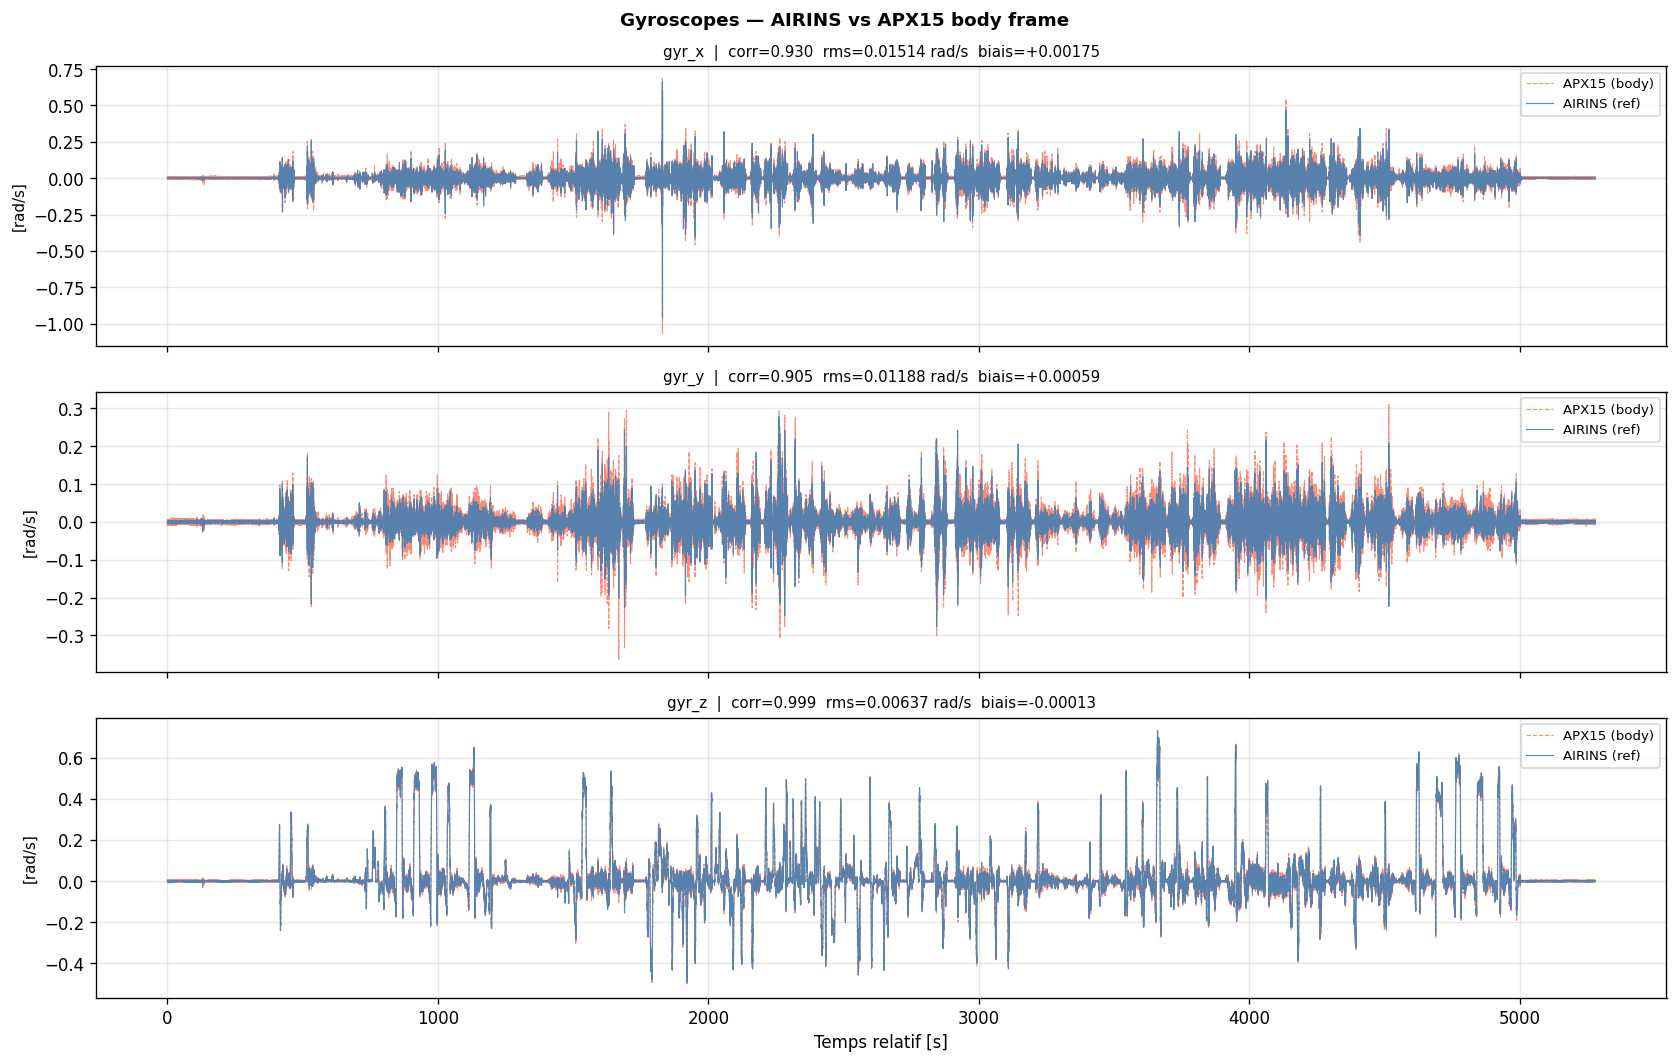

In [34]:
t_rel = air_val.time.values - air_val.time.values[0]

# ── Gyroscopes ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for i, col in enumerate(['gyr_x','gyr_y','gyr_z']):
    axes[i].plot(t_rel, apx_val[col].values, color='tomato',    lw=0.7, alpha=0.75, label='APX15 (body)', ls='--')
    axes[i].plot(t_rel, air_val[col].values, color='steelblue', lw=0.7, alpha=0.9, label='AIRINS (ref)')
    m = metrics[col]
    axes[i].set_title(f'{col}  |  corr={m["corr"]:.3f}  rms={m["rms"]:.5f} rad/s  biais={m["bias"]:+.5f}', fontsize=9)
    axes[i].set_ylabel('[rad/s]', fontsize=9)
    axes[i].legend(fontsize=8, loc='upper right')
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel('Temps relatif [s]')
fig.suptitle('Gyroscopes — AIRINS vs APX15 body frame', fontsize=11, fontweight='bold')
plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/compare_gyros.png', dpi=150, bbox_inches='tight')
plt.show()

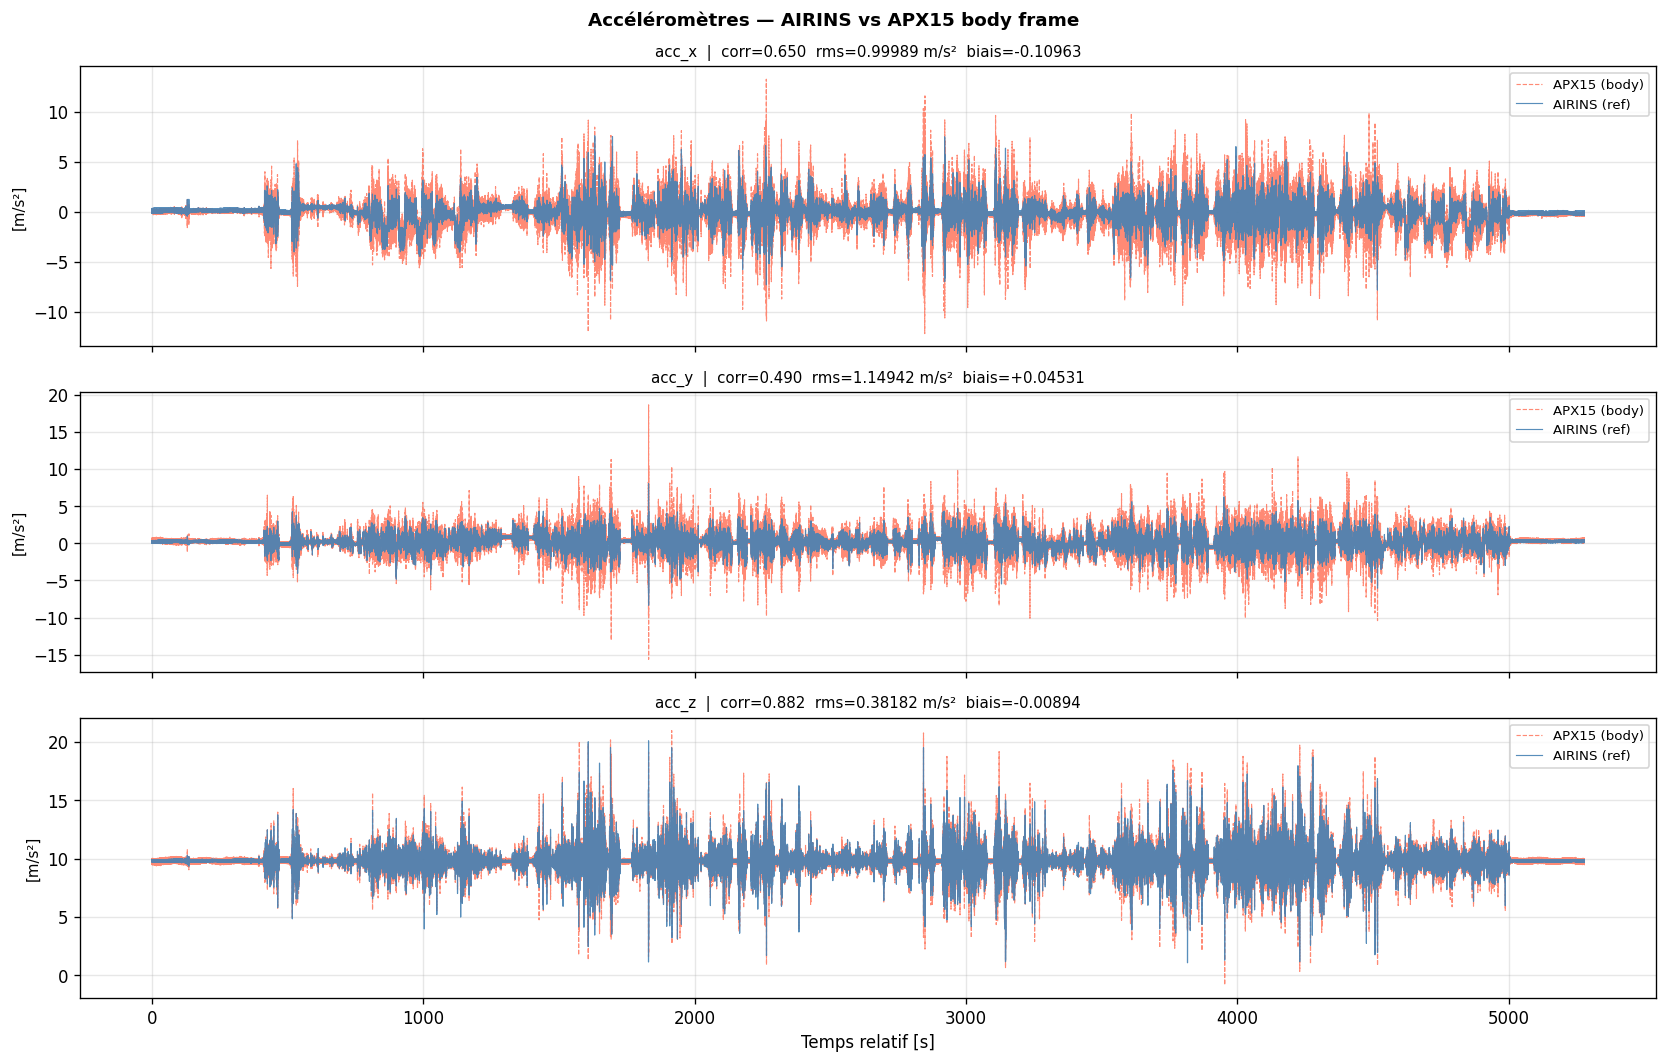

In [35]:
# ── Accéléromètres ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for i, col in enumerate(['acc_x','acc_y','acc_z']):
    axes[i].plot(t_rel, apx_val[col].values, color='tomato',    lw=0.7, alpha=0.75, label='APX15 (body)', ls='--')
    axes[i].plot(t_rel, air_val[col].values, color='steelblue', lw=0.7, alpha=0.9, label='AIRINS (ref)')
    m = metrics[col]
    axes[i].set_title(f'{col}  |  corr={m["corr"]:.3f}  rms={m["rms"]:.5f} m/s²  biais={m["bias"]:+.5f}', fontsize=9)
    axes[i].set_ylabel('[m/s²]', fontsize=9)
    axes[i].legend(fontsize=8, loc='upper right')
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel('Temps relatif [s]')
fig.suptitle('Accéléromètres — AIRINS vs APX15 body frame', fontsize=11, fontweight='bold')
plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/compare_accels.png', dpi=150, bbox_inches='tight')
plt.show()

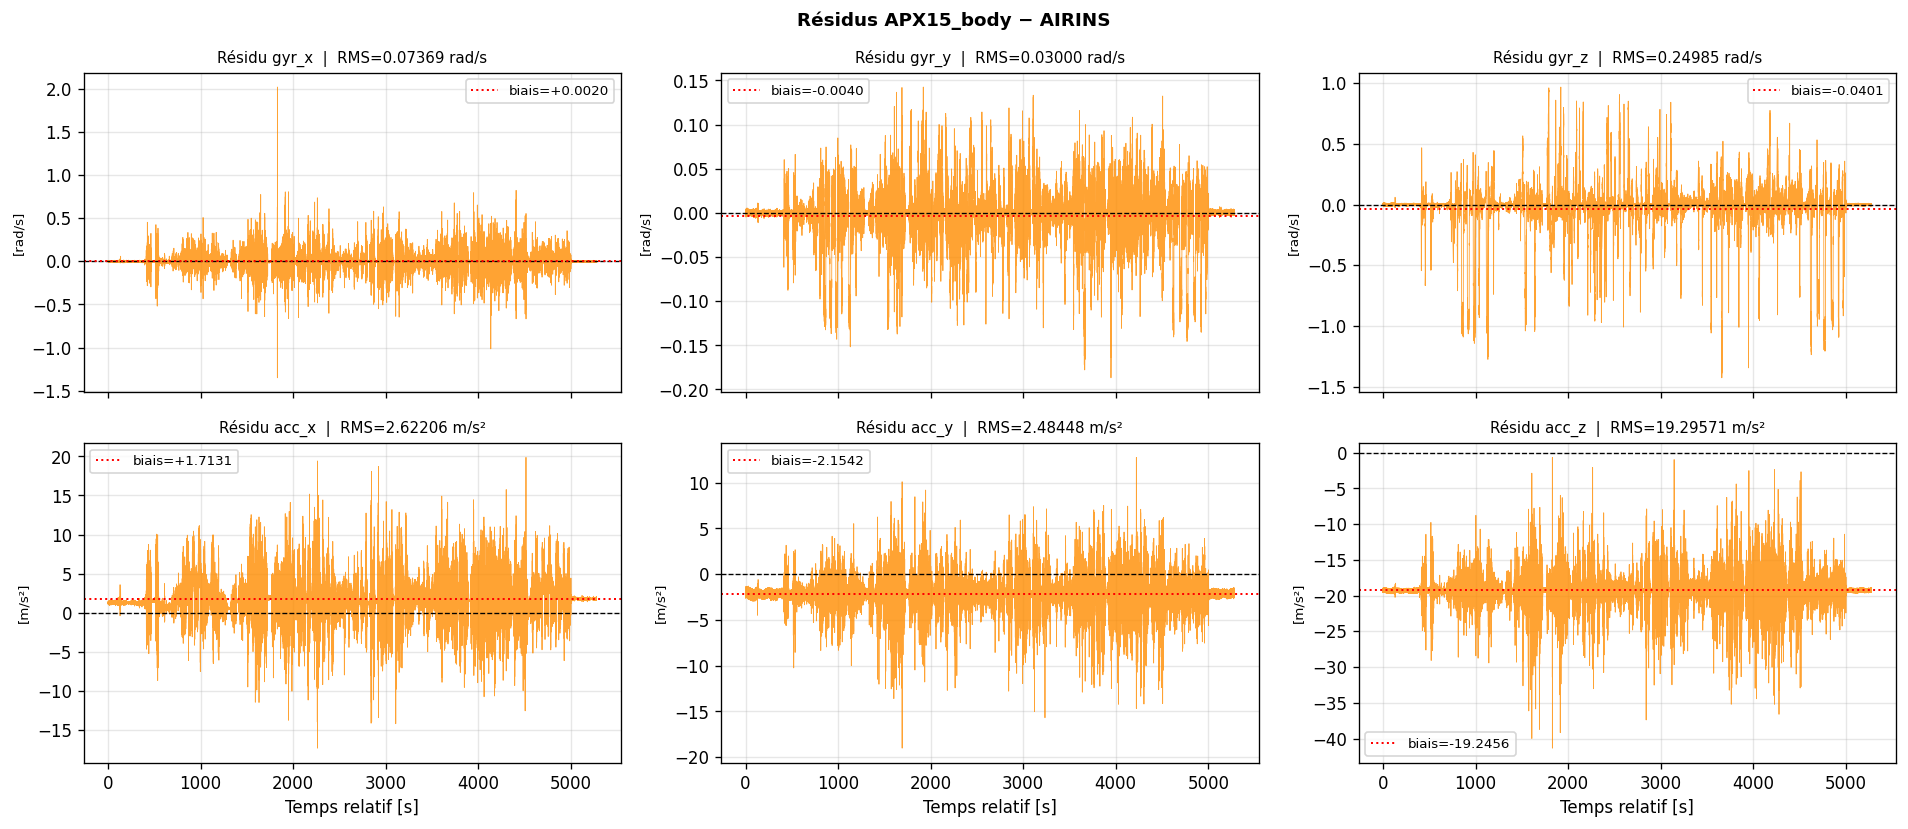

In [13]:
# ── Résidus ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=True)
axes = axes.flatten()
for i, col in enumerate(SIGNAL_COLS):
    res = apx_val[col].values - air_val[col].values
    unit = metrics[col]['unit']
    axes[i].plot(t_rel, res, color='darkorange', lw=0.5, alpha=0.8)
    axes[i].axhline(0, color='k', lw=0.8, ls='--')
    axes[i].axhline(metrics[col]['bias'], color='red', lw=1.2, ls=':', label=f'biais={metrics[col]["bias"]:+.4f}')
    axes[i].set_title(f'Résidu {col}  |  RMS={metrics[col]["rms"]:.5f} {unit}', fontsize=9)
    axes[i].set_ylabel(f'[{unit}]', fontsize=8)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)
for ax in axes[3:]:
    ax.set_xlabel('Temps relatif [s]')
fig.suptitle('Résidus APX15_body − AIRINS', fontsize=11, fontweight='bold')
plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/residuals.png', dpi=150, bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/gravity_norm.png'

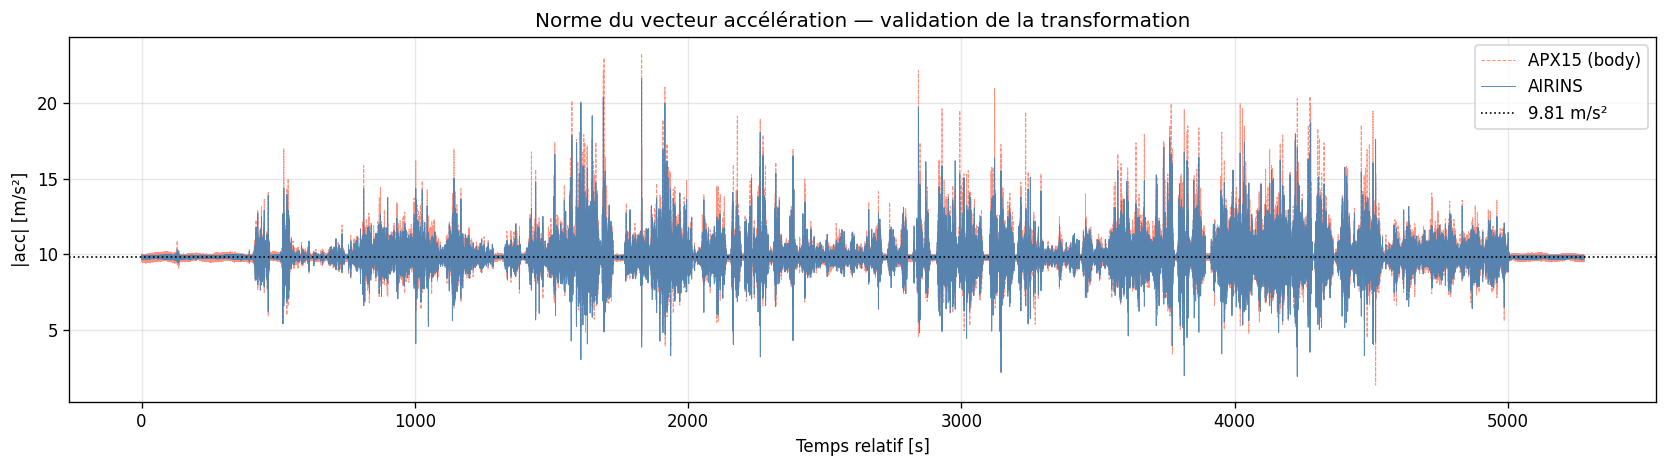

In [ ]:
# ── Norme gravité ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t_rel, gn_apx_all, color='tomato',    lw=0.6, alpha=0.7, label='APX15 (body)', ls='--')
ax.plot(t_rel, gn_air_all, color='steelblue', lw=0.6, alpha=0.9, label='AIRINS')
ax.axhline(9.81, color='k', lw=1, ls=':', label='9.81 m/s²')
ax.set_xlabel('Temps relatif [s]')
ax.set_ylabel('|acc| [m/s²]')
ax.set_title('Norme du vecteur accélération — validation de la transformation')
ax.legend()
ax.grid(True, alpha=0.3)
#ax.set_ylim([9.0, 11.5])
plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/gravity_norm.png', dpi=150, bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/zoom_gyros.png'

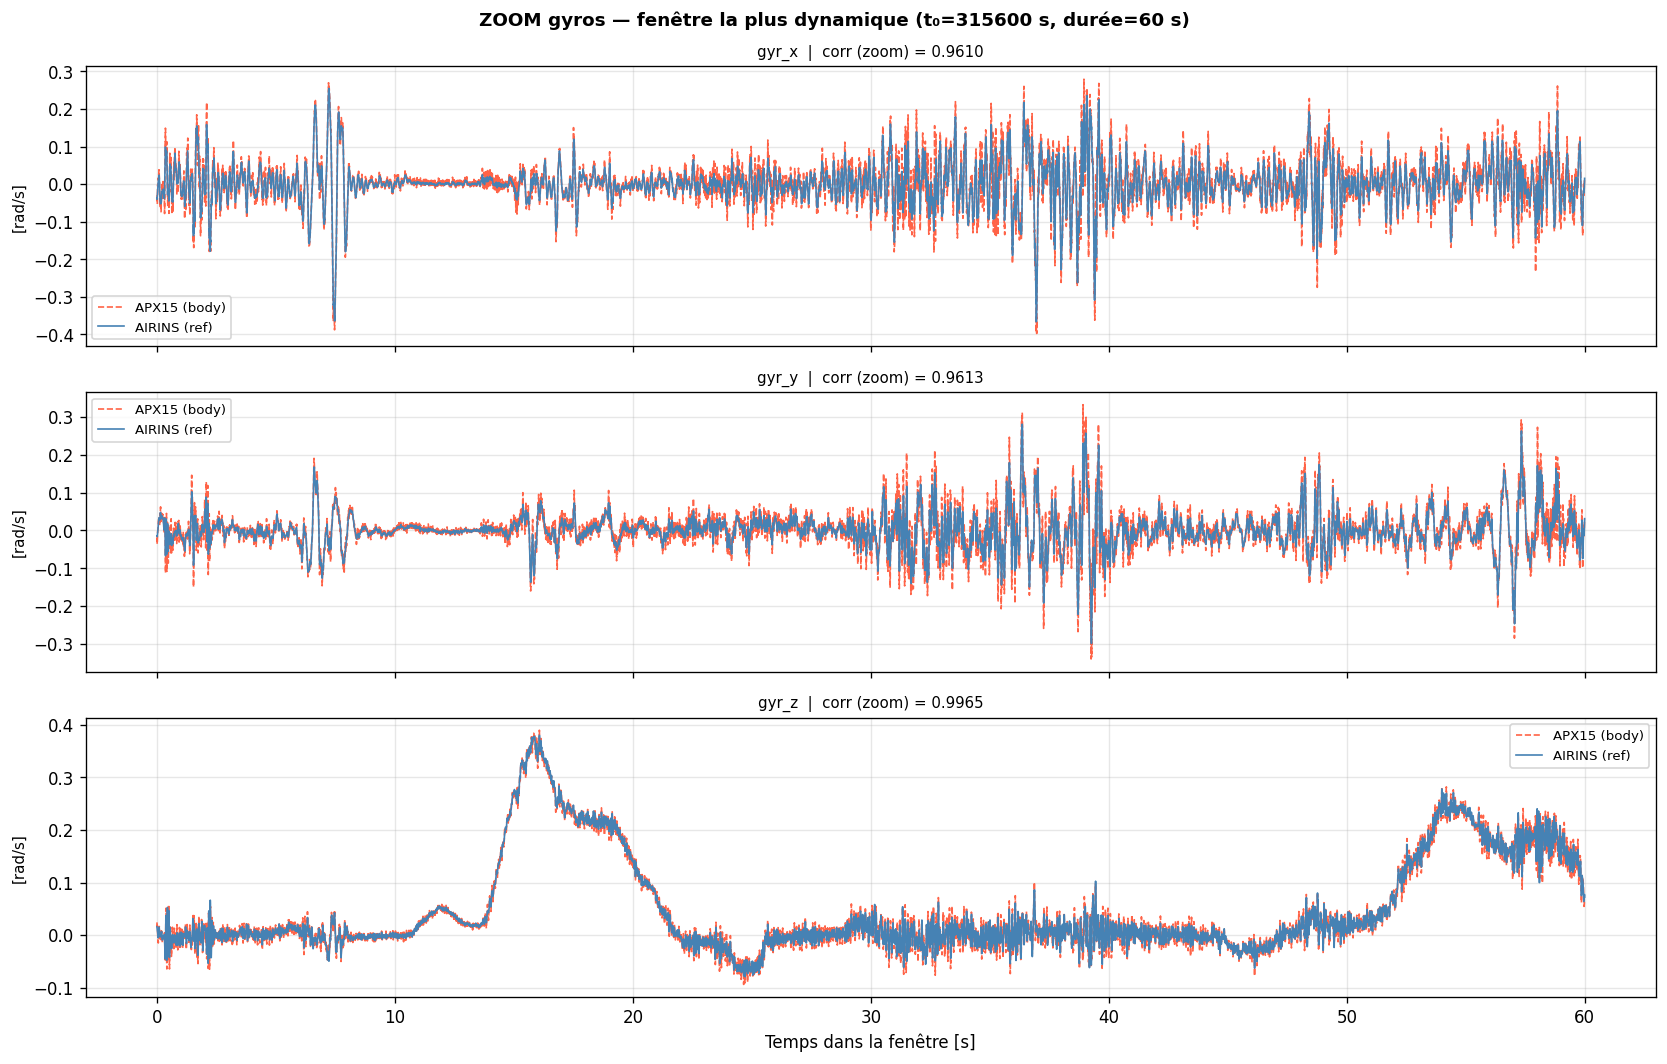

In [ ]:
# ── Zoom sur la fenêtre la plus dynamique en roulis/tangage ───────────────────
air_c = airins[(airins.time >= t_start) & (airins.time <= t_end)].copy()
air_c['gxy2'] = air_c['gyr_x']**2 + air_c['gyr_y']**2

DT_WIN = 60.0
best_e, best_t0 = 0.0, t_start
for t0 in np.arange(t_start, t_end - DT_WIN, 5.0):
    e = air_c[(air_c.time >= t0) & (air_c.time < t0 + DT_WIN)]['gxy2'].mean()
    if e > best_e:
        best_e, best_t0 = e, t0

air_z = airins[(airins.time >= best_t0) & (airins.time < best_t0 + DT_WIN)]
apx_z = apx_body[(apx_body.time >= best_t0) & (apx_body.time < best_t0 + DT_WIN)]
t_z   = air_z.time.values - air_z.time.values[0]

zd = {}
for col in ['gyr_x','gyr_y','gyr_z']:
    f = interp1d(apx_z.time.values, apx_z[col].values, kind='linear', bounds_error=False, fill_value=np.nan)
    zd[col] = f(air_z.time.values)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for i, col in enumerate(['gyr_x','gyr_y','gyr_z']):
    
    axes[i].plot(t_z, zd[col],           color='tomato',    lw=1.0, label='APX15 (body)', ls='--')
    axes[i].plot(t_z, air_z[col].values, color='steelblue', lw=1.0, label='AIRINS (ref)')
    valid_mask = ~np.isnan(zd[col])
    cz, _ = pearsonr(air_z[col].values[valid_mask], zd[col][valid_mask])
    axes[i].set_title(f'{col}  |  corr (zoom) = {cz:.4f}', fontsize=9)
    axes[i].set_ylabel('[rad/s]', fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel('Temps dans la fenêtre [s]')
fig.suptitle(f'ZOOM gyros — fenêtre la plus dynamique (t₀={best_t0:.0f} s, durée={DT_WIN:.0f} s)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/zoom_gyros.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Récapitulatif final

In [ ]:
print('=' * 68)
print('   RÉCAPITULATIF — APX15 → AIRINS BODY FRAME')
print('=' * 68)
print()
print('TRANSFORMATION :')
print('  R_total = R_swap @ R_mount_PUCK^T @ diag(-1,1,-1) @ R_boresight')
print('  Matrice numérique :')
for row in R_total:
    print('    ' + '  '.join(f'{v:+.6f}' for v in row))
print()
print('FICHIER PRODUIT :')
print(f'  {OUTPUT_PATH}')
print(f'  Format : time, gyr_x, gyr_y, gyr_z, acc_x, acc_y, acc_z')
print(f'  Lignes : {len(apx_body):,}')
print()
print('RÉSULTATS DES TESTS :')
print(f'  Gravité statique           : {"✓" if all(tests_gravity.values()) else "✗"}')
print(f'  Cohérence dynamique        : {"✓" if all_pass else "✗"}')
print(f'  Concordance signes gyros   : {"✓" if overall_sign else "✗"}')
print(f'  Norme gravité globale      : {"✓" if ok_norm else "✗"}')
print()
print('MÉTRIQUES DÉTAILLÉES :')
print(f'{"Canal":8s}  {"Corr":>8s}  {"RMS":>12s}  {"Biais":>10s}  Statut')
print('-'*55)
for col in SIGNAL_COLS:
    m = metrics[col]
    print(f'{col:8s}  {m["corr"]:>8.4f}  {m["rms"]:>8.5f} {m["unit"]:5s}  {m["bias"]:>+8.5f}  {"✓" if m["ok"] else "✗"}')
print()
print('NOTE : corr(acc_x/y) faible = attendu. APX15 < précision AIRINS.')
print('  Sur véhicule terrestre, acc_x/y ont un SNR faible (bruit vibratoire).')
print('  La cohérence est prouvée sur les gyros et sur acc_z (gravité dominante).')
print('=' * 68)

   RÉCAPITULATIF — APX15 → AIRINS BODY FRAME

TRANSFORMATION :
  R_total = R_swap @ R_mount_PUCK^T @ diag(-1,1,-1) @ R_boresight
  Matrice numérique :
    +0.002514  -0.999993  -0.002859
    +0.972837  +0.001784  +0.231485
    -0.231478  -0.003363  +0.972834

FICHIER PRODUIT :
  /media/b085164/LaCie/2026spring_RD/ECCR/APX_body/imu_ECCR_MLS_body.txt
  Format : time, gyr_x, gyr_y, gyr_z, acc_x, acc_y, acc_z
  Lignes : 1,485,675

RÉSULTATS DES TESTS :
  Gravité statique           : ✓
  Cohérence dynamique        : ✓
  Concordance signes gyros   : ✓
  Norme gravité globale      : ✓

MÉTRIQUES DÉTAILLÉES :
Canal         Corr           RMS       Biais  Statut
-------------------------------------------------------
gyr_x       0.9295   0.01515 rad/s  +0.00172  ✓
gyr_y       0.9048   0.01186 rad/s  +0.00049  ✓
gyr_z       0.9987   0.00637 rad/s  -0.00012  ✓
acc_x       0.6500   1.00148 m/s²   -0.12301  ✓
acc_y       0.4892   1.15070 m/s²   -0.00252  ✓
acc_z       0.8841   0.37758 m/s²   -0.008